# Notebook 5 — LSTM on Raw Point Cloud (No Feature Engineering)
**Sensor:** TI IWR6843ISK (77 GHz)  
**Dataset:** `Data/Research Data-New/Single Activity/3D data/`  
**Target:** Classify Sitting · Standing · Waiving · Walking  
**Train distances:** 1 m · 2 m · 3 m  
**Test distances:** 4 m · 5 m  

### Motivation
Notebooks 3 & 4 used hand-crafted per-frame statistics (mean, std, etc.) as LSTM input.  
This notebook feeds **raw detected points directly** to the LSTM — no feature engineering —  
to test whether the model can discover useful patterns on its own.

### Raw-point representation
Each radar frame contains a **variable number of detected points**.  
To get a fixed-size input per frame:
- Points are **sorted by SNR descending** (keep most reliable detections first)
- Padded with **zeros** if fewer than `MAX_POINTS` detected
- **Truncated** to `MAX_POINTS` if more detected (affects <1 % of frames)
- Each point has **8 raw attributes**: `x, y, z, doppler, range, aoa, snr, noise`

```
Frame  →  (MAX_POINTS=10) × (8 raw features)  →  flatten  →  80-dim vector
Window →  20 consecutive frames  →  shape (20, 80)
LSTM   →  Input(20, 80) → LSTM(64) → Dense(32) → Dense(4)
```

### Pipeline
1. Setup & constants  
2. Raw point loading & fixed-size frame construction  
3. Sliding-window sequence construction  
4. Normalisation & label encoding  
5. LSTM model definition  
6. Training with callbacks  
7. Evaluation — overall & per-distance  
8. Confusion matrix & classification report  
9. Learning-curve plots  
10. Comparison with feature-engineered model (Notebook 4)  
11. Model save  

In [1]:
# ── 1. Setup ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score, f1_score
)

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, LayerNormalization, Masking
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

# ── Paths & constants ─────────────────────────────────────────────────────────
DATA_ROOT = Path('Data/Research Data-New/Single Activity/3D data')

ACTIVITIES  = ['Sitting', 'Standing', 'Waiving', 'Walking']
TRAIN_DISTS = ['1 m', '2 m', '3 m']
TEST_DISTS  = ['4 m', '5 m']
NUM_CLASSES = len(ACTIVITIES)

# Raw point representation
# p99 of points-per-frame = 8, max = 13  →  MAX_POINTS=10 clips <1% of frames
MAX_POINTS  = 10
RAW_FEATS   = ['x', 'y', 'z', 'doppler', 'range', 'aoa', 'snr', 'noise']
N_RAW       = len(RAW_FEATS)              # 8 per point
FRAME_DIM   = MAX_POINTS * N_RAW         # 80 values per frame

# Sequence hyperparameters
WINDOW_SIZE = 20
STRIDE      = 5

print(f'TF version   : {tf.__version__}')
print(f'Activities   : {ACTIVITIES}')
print(f'Train dists  : {TRAIN_DISTS}')
print(f'Test  dists  : {TEST_DISTS}')
print(f'MAX_POINTS   : {MAX_POINTS}  |  RAW_FEATS: {N_RAW}  |  FRAME_DIM: {FRAME_DIM}')
print(f'Window size  : {WINDOW_SIZE} frames  |  Stride: {STRIDE}')

TF version   : 2.21.0
Activities   : ['Sitting', 'Standing', 'Waiving', 'Walking']
Train dists  : ['1 m', '2 m', '3 m']
Test  dists  : ['4 m', '5 m']
MAX_POINTS   : 10  |  RAW_FEATS: 8  |  FRAME_DIM: 80
Window size  : 20 frames  |  Stride: 5


## 2. Raw Point Loading & Fixed-Size Frame Construction

Each frame is represented as a **(MAX_POINTS × 8)** matrix, flattened to an **80-dim vector**.

**Padding strategy:**
- Points sorted by SNR descending → highest-quality detections come first
- If a frame has fewer than `MAX_POINTS` points → remaining rows filled with **zeros**
- Zero rows are distinguishable from real detections because real points always have non-zero range
- A `Masking` layer in the model will learn to ignore zero-padded steps at the sequence level

In [2]:
def frame_to_flat_vector(group, max_points=MAX_POINTS, raw_feats=RAW_FEATS):
    """
    Convert one frame's point cloud (variable rows) into a fixed-size flat vector.
    Sort by SNR desc, pad/truncate to max_points, then flatten.
    Returns: 1-D array of shape (max_points * len(raw_feats),)
    """
    pts = group[raw_feats].values.astype(np.float32)
    # sort by SNR descending (column index 6)
    snr_col = raw_feats.index('snr')
    pts     = pts[pts[:, snr_col].argsort()[::-1]]

    n = len(pts)
    if n >= max_points:
        pts = pts[:max_points]                         # truncate
    else:
        pad = np.zeros((max_points - n, len(raw_feats)), dtype=np.float32)
        pts = np.vstack([pts, pad])                   # zero-pad

    return pts.flatten()                               # (max_points * N_RAW,)


def extract_raw_frames(act, dist):
    """
    Load PointCloud_snr.csv for one recording.
    Returns a DataFrame with one row per frame:
      columns = [frame_number, activity, distance, f0 … f79]
    """
    csv_path = DATA_ROOT / act / dist / 'PointCloud_snr.csv'
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    feat_col_names = [f'f{i}' for i in range(FRAME_DIM)]

    rows = []
    for frame_num, grp in df.groupby('frame_number', sort=True):
        vec = frame_to_flat_vector(grp)
        rows.append([frame_num] + vec.tolist())

    frame_df = pd.DataFrame(rows, columns=['frame_number'] + feat_col_names)
    frame_df['activity'] = act
    frame_df['distance'] = dist
    return frame_df


def build_raw_dataset(distances):
    parts = []
    for act in ACTIVITIES:
        for dist in distances:
            parts.append(extract_raw_frames(act, dist))
    return pd.concat(parts, ignore_index=True)


FLAT_COLS = [f'f{i}' for i in range(FRAME_DIM)]

print('Loading training data  (1 m, 2 m, 3 m)...')
train_raw = build_raw_dataset(TRAIN_DISTS)
print(f'  {len(train_raw)} frames  |  {train_raw["activity"].value_counts().to_dict()}')

print('Loading test data      (4 m, 5 m)...')
test_raw  = build_raw_dataset(TEST_DISTS)
print(f'  {len(test_raw)} frames  |  {test_raw["activity"].value_counts().to_dict()}')

print(f'\nFrame vector shape: {FRAME_DIM} = {MAX_POINTS} points × {N_RAW} features')
print(f'Example frame (first recording, first frame):')
sample = train_raw[FLAT_COLS].values[0].reshape(MAX_POINTS, N_RAW)
print(pd.DataFrame(sample, columns=RAW_FEATS).round(3).to_string())

Loading training data  (1 m, 2 m, 3 m)...
  1469 frames  |  {'Standing': 426, 'Sitting': 406, 'Walking': 337, 'Waiving': 300}
Loading test data      (4 m, 5 m)...
  1009 frames  |  {'Standing': 297, 'Sitting': 277, 'Walking': 221, 'Waiving': 214}

Frame vector shape: 80 = 10 points × 8 features
Example frame (first recording, first frame):
       x      y      z  doppler  range      aoa   snr  noise
0 -0.116  0.042 -0.026    0.000  0.126  160.195  21.8   66.8
1  0.000  1.259  1.227   -1.023  1.758   90.000  19.8   41.6
2 -0.648  1.548 -0.526   -1.023  1.758  112.704  19.8   41.6
3  0.139  1.499  0.062    0.000  1.507   84.712  17.6   65.3
4  0.000  0.000  0.000    0.000  0.000    0.000   0.0    0.0
5  0.000  0.000  0.000    0.000  0.000    0.000   0.0    0.0
6  0.000  0.000  0.000    0.000  0.000    0.000   0.0    0.0
7  0.000  0.000  0.000    0.000  0.000    0.000   0.0    0.0
8  0.000  0.000  0.000    0.000  0.000    0.000   0.0    0.0
9  0.000  0.000  0.000    0.000  0.000    0.000 

Points-per-frame distribution across all recordings:
  min=1  mean=2.4  p50=2  p90=5  p99=8  max=13
  Frames needing padding   (< 10 pts): 99.7%
  Frames needing truncation(> 10 pts): 0.1%


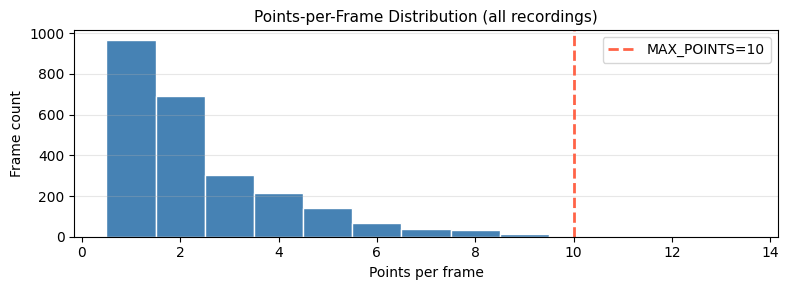

In [3]:
# ── Point-count statistics (how often padding / truncation occurs) ─────────────
print('Points-per-frame distribution across all recordings:')
all_ppf = []
for act in ACTIVITIES:
    for dist in TRAIN_DISTS + TEST_DISTS:
        df = pd.read_csv(DATA_ROOT / act / dist / 'PointCloud_snr.csv')
        df.columns = df.columns.str.strip()
        all_ppf.extend(df.groupby('frame_number').size().tolist())

ppf = np.array(all_ppf)
print(f'  min={ppf.min()}  mean={ppf.mean():.1f}  p50={np.percentile(ppf,50):.0f}'
      f'  p90={np.percentile(ppf,90):.0f}  p99={np.percentile(ppf,99):.0f}  max={ppf.max()}')
print(f'  Frames needing padding   (< {MAX_POINTS} pts): {(ppf < MAX_POINTS).mean()*100:.1f}%')
print(f'  Frames needing truncation(> {MAX_POINTS} pts): {(ppf > MAX_POINTS).mean()*100:.1f}%')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ppf, bins=range(1, ppf.max() + 2), edgecolor='white', color='steelblue', align='left')
ax.axvline(MAX_POINTS, color='tomato', linewidth=2, linestyle='--', label=f'MAX_POINTS={MAX_POINTS}')
ax.set_title('Points-per-Frame Distribution (all recordings)', fontsize=11)
ax.set_xlabel('Points per frame'); ax.set_ylabel('Frame count')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('raw_ppf_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Sliding-Window Sequence Construction

Each recording → overlapping windows of `WINDOW_SIZE` consecutive flat frame vectors.  
Windows are built **per-recording** so they never cross recording boundaries.

In [4]:
def build_windows(raw_df, window_size=WINDOW_SIZE, stride=STRIDE):
    """
    Returns:
        X : ndarray  (N, window_size, FRAME_DIM)
        y : ndarray  (N,)  string activity labels
        d : ndarray  (N,)  distance labels
    """
    seqs, labels, dists = [], [], []

    for (act, dist), grp in raw_df.groupby(['activity', 'distance'], sort=False):
        grp    = grp.sort_values('frame_number').reset_index(drop=True)
        values = grp[FLAT_COLS].values.astype(np.float32)  # (T, FRAME_DIM)
        T      = len(values)

        for start in range(0, T - window_size + 1, stride):
            seqs.append(values[start : start + window_size])
            labels.append(act)
            dists.append(dist)

    return (
        np.array(seqs,  dtype=np.float32),
        np.array(labels),
        np.array(dists)
    )


X_train_raw, y_train_str, d_train = build_windows(train_raw)
X_test_raw,  y_test_str,  d_test  = build_windows(test_raw)

print(f'Train windows: {X_train_raw.shape}  labels: {pd.Series(y_train_str).value_counts().to_dict()}')
print(f'Test  windows: {X_test_raw.shape}   labels: {pd.Series(y_test_str).value_counts().to_dict()}')
print(f'\nInput to LSTM: (batch, {WINDOW_SIZE} timesteps, {FRAME_DIM} features)')
print(f'  Each timestep = {MAX_POINTS} points × {N_RAW} raw attributes, flattened')

Train windows: (253, 20, 80)  labels: {'Standing': 75, 'Sitting': 71, 'Walking': 58, 'Waiving': 49}
Test  windows: (175, 20, 80)   labels: {'Standing': 53, 'Sitting': 49, 'Walking': 37, 'Waiving': 36}

Input to LSTM: (batch, 20 timesteps, 80 features)
  Each timestep = 10 points × 8 raw attributes, flattened


## 4. Normalisation & Label Encoding

**Important:** StandardScaler is fit **only on training data** and applied to test data.  
Zero-padded slots (all-zero rows) remain all-zero after scaling because the scaler subtracts  
the mean and divides by std — padding zeros will map to non-zero values.  
This is acceptable: the model will learn that these patterns correspond to "no detection".

X_train: (253, 20, 80)  y_train: (253, 4)
X_test : (175, 20, 80)   y_test : (175, 4)
Classes: [np.str_('Sitting'), np.str_('Standing'), np.str_('Waiving'), np.str_('Walking')]


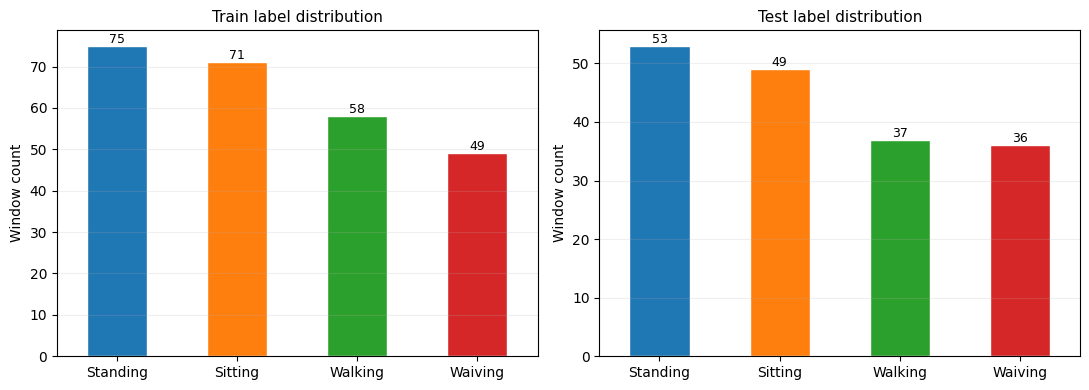

In [5]:
N_train, T, F = X_train_raw.shape
N_test        = X_test_raw.shape[0]

scaler     = StandardScaler()
X_train_2d = X_train_raw.reshape(-1, F)
X_test_2d  = X_test_raw.reshape(-1, F)

scaler.fit(X_train_2d)
X_train = scaler.transform(X_train_2d).reshape(N_train, T, F).astype(np.float32)
X_test  = scaler.transform(X_test_2d ).reshape(N_test,  T, F).astype(np.float32)

le = LabelEncoder()
le.fit(ACTIVITIES)

y_train_idx = le.transform(y_train_str)
y_test_idx  = le.transform(y_test_str)
y_train_oh  = to_categorical(y_train_idx, num_classes=NUM_CLASSES)
y_test_oh   = to_categorical(y_test_idx,  num_classes=NUM_CLASSES)

print(f'X_train: {X_train.shape}  y_train: {y_train_oh.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test_oh.shape}')
print(f'Classes: {list(le.classes_)}')

# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, counts, title in zip(
    axes,
    [pd.Series(y_train_str).value_counts(), pd.Series(y_test_str).value_counts()],
    ['Train label distribution', 'Test label distribution']
):
    counts.plot.bar(ax=ax, color=sns.color_palette('tab10', NUM_CLASSES), edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Window count')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(True, alpha=0.2, axis='y')
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('raw_label_dist.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. LSTM Model Definition

Same depth as Notebooks 3 & 4 for a fair comparison — only the input dimension changes.

```
Input  (20 frames × 80 raw values)
  └─ LSTM(64) → LayerNorm → Dropout(0.3)
       └─ Dense(32, relu) → Dropout(0.25)
            └─ Dense(4, softmax)
```

The wider input (80 vs 16 features in Nb4) means the LSTM has more raw signal per timestep  
but no domain knowledge baked in — it must learn what matters from scratch.

In [6]:
def build_lstm_model(window_size=WINDOW_SIZE, frame_dim=FRAME_DIM,
                     num_classes=NUM_CLASSES):
    inp = Input(shape=(window_size, frame_dim), name='raw_frame_sequence')

    x   = LSTM(64, return_sequences=False, name='lstm_1')(inp)
    x   = LayerNormalization()(x)
    x   = Dropout(0.30)(x)

    x   = Dense(32, activation='relu')(x)
    x   = Dropout(0.25)(x)
    out = Dense(num_classes, activation='softmax', name='class_output')(x)

    model = Model(inputs=inp, outputs=out, name='LSTM_RawPoints')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = build_lstm_model()
model.summary()
print(f'\nParameters per training sample: {model.count_params() / len(X_train):.0f}')

Model: "LSTM_RawPoints"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ raw_frame_sequence (InputLayer)      │ (None, 20, 80)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          37,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization                  │ (None, 64)                  │             128 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_output (Dense)                 │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,460 (154.14 KB)

 Trainable params: 39,460 (154.14 KB)

 Non-trainable params: 0 (0.00 B)


Parameters per training sample: 156


## 6. Training

In [7]:
EPOCHS     = 150      # extra budget since raw input is harder to learn from
BATCH_SIZE = 16
VAL_SPLIT  = 0.15

os.makedirs('checkpoints', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8,
        min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        'checkpoints/best_model_raw.keras',
        monitor='val_accuracy', save_best_only=True,
        mode='max', verbose=0
    ),
]

history = model.fit(
    X_train, y_train_oh,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')

Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.3023 - loss: 1.7321 - val_accuracy: 0.8421 - val_loss: 0.6547 - learning_rate: 0.0010
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5581 - loss: 1.0239 - val_accuracy: 0.8421 - val_loss: 0.5753 - learning_rate: 0.0010
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5488 - loss: 0.9036 - val_accuracy: 0.8684 - val_loss: 0.5044 - learning_rate: 0.0010
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6372 - loss: 0.8179 - val_accuracy: 0.9211 - val_loss: 0.4302 - learning_rate: 0.0010
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7023 - loss: 0.6408 - val_accuracy: 0.9474 - val_loss: 0.3353 - learning_rate: 0.0010
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7442 - loss: 0.6275 - val_accuracy: 0.9474 - val_loss: 0.2878 - learning_rate: 0.0010
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7535 - loss: 0.5962 - 

## 7. Overall Evaluation on Test Set (4 m + 5 m)

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f'Test loss    : {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test_idx

bal_acc  = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f'Balanced accuracy: {bal_acc:.4f}')
print(f'Macro F1-score   : {macro_f1:.4f}')

print('\nClassification report:')
print(classification_report(y_true, y_pred,
                             target_names=le.classes_, zero_division=0))

Test loss    : 0.9764
Test accuracy: 0.6343
Balanced accuracy: 0.6282
Macro F1-score   : 0.6493

Classification report:
              precision    recall  f1-score   support

     Sitting       0.64      0.51      0.57        49
    Standing       0.48      0.77      0.59        53
     Waiving       0.77      0.47      0.59        36
     Walking       0.97      0.76      0.85        37

    accuracy                           0.63       175
   macro avg       0.72      0.63      0.65       175
weighted avg       0.69      0.63      0.64       175



## 8. Confusion Matrix

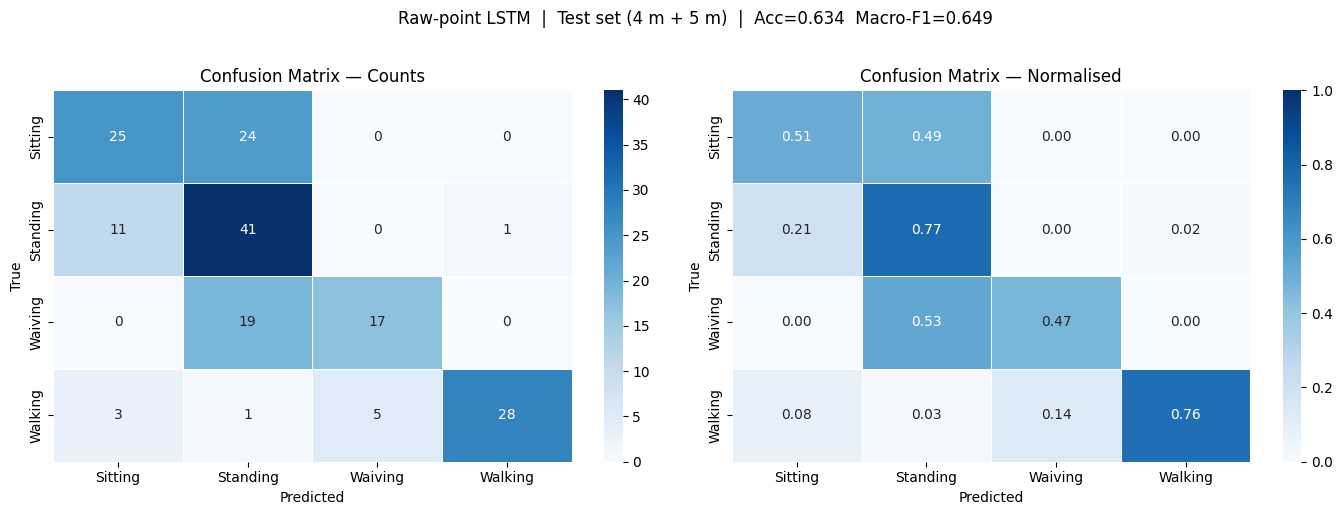

In [9]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[0], linewidths=0.4)
axes[0].set_title('Confusion Matrix — Counts', fontsize=12)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            vmin=0, vmax=1, ax=axes[1], linewidths=0.4)
axes[1].set_title('Confusion Matrix — Normalised', fontsize=12)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle(
    f'Raw-point LSTM  |  Test set (4 m + 5 m)  |  Acc={test_acc:.3f}  Macro-F1={macro_f1:.3f}',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('raw_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Per-Distance Performance Breakdown

In [10]:
print('=' * 55)
print('Per-Distance Performance on Test Set')
print('=' * 55)

dist_metrics = []
for dist in TEST_DISTS:
    mask  = d_test == dist
    if mask.sum() == 0:
        continue
    yt_d  = y_true[mask]
    yp_d  = y_pred[mask]
    acc_d = accuracy_score(yt_d, yp_d)
    f1_d  = f1_score(yt_d, yp_d, average='macro', zero_division=0)
    bal_d = balanced_accuracy_score(yt_d, yp_d)
    dist_metrics.append({'Distance': dist, 'Samples': int(mask.sum()),
                          'Accuracy': round(acc_d, 4),
                          'Balanced Acc': round(bal_d, 4),
                          'Macro F1': round(f1_d, 4)})
    print(f'\n  Distance: {dist}  ({mask.sum()} windows)')
    print(f'  Accuracy={acc_d:.4f}  BalAcc={bal_d:.4f}  MacroF1={f1_d:.4f}')
    print(classification_report(yt_d, yp_d, target_names=le.classes_,
                                  zero_division=0, digits=3))

dist_df = pd.DataFrame(dist_metrics)
print(dist_df.to_string(index=False))

Per-Distance Performance on Test Set

  Distance: 4 m  (82 windows)
  Accuracy=0.7683  BalAcc=0.7806  MacroF1=0.7719
              precision    recall  f1-score   support

     Sitting      0.917     0.458     0.611        24
    Standing      0.622     0.958     0.754        24
     Waiving      0.810     1.000     0.895        17
     Walking      1.000     0.706     0.828        17

    accuracy                          0.768        82
   macro avg      0.837     0.781     0.772        82
weighted avg      0.825     0.768     0.757        82


  Distance: 5 m  (93 windows)
  Accuracy=0.5161  BalAcc=0.4952  MacroF1=0.4677
              precision    recall  f1-score   support

     Sitting      0.519     0.560     0.538        25
    Standing      0.375     0.621     0.468        29
     Waiving      0.000     0.000     0.000        19
     Walking      0.941     0.800     0.865        20

    accuracy                          0.516        93
   macro avg      0.459     0.495     0.46

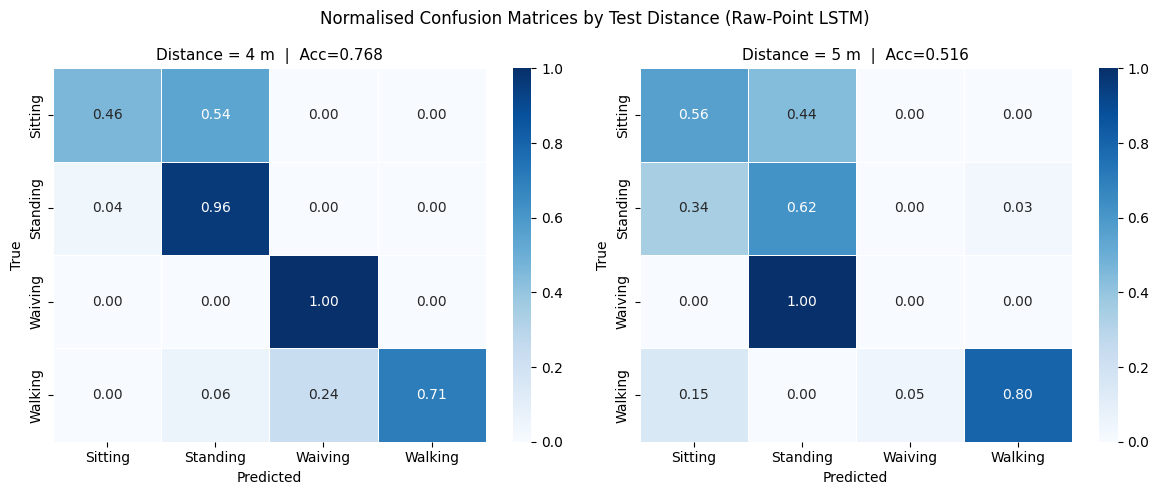

In [11]:
# Per-distance confusion matrices
fig, axes = plt.subplots(1, len(TEST_DISTS), figsize=(6 * len(TEST_DISTS), 5))
if len(TEST_DISTS) == 1:
    axes = [axes]

for ax, dist in zip(axes, TEST_DISTS):
    mask = d_test == dist
    if mask.sum() == 0:
        ax.set_visible(False)
        continue
    cm_d      = confusion_matrix(y_true[mask], y_pred[mask])
    cm_d_norm = cm_d.astype(float) / cm_d.sum(axis=1, keepdims=True)
    sns.heatmap(cm_d_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                vmin=0, vmax=1, ax=ax, linewidths=0.4)
    acc_d = accuracy_score(y_true[mask], y_pred[mask])
    ax.set_title(f'Distance = {dist}  |  Acc={acc_d:.3f}', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle('Normalised Confusion Matrices by Test Distance (Raw-Point LSTM)', fontsize=12)
plt.tight_layout()
plt.savefig('raw_cm_per_distance.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Learning Curves

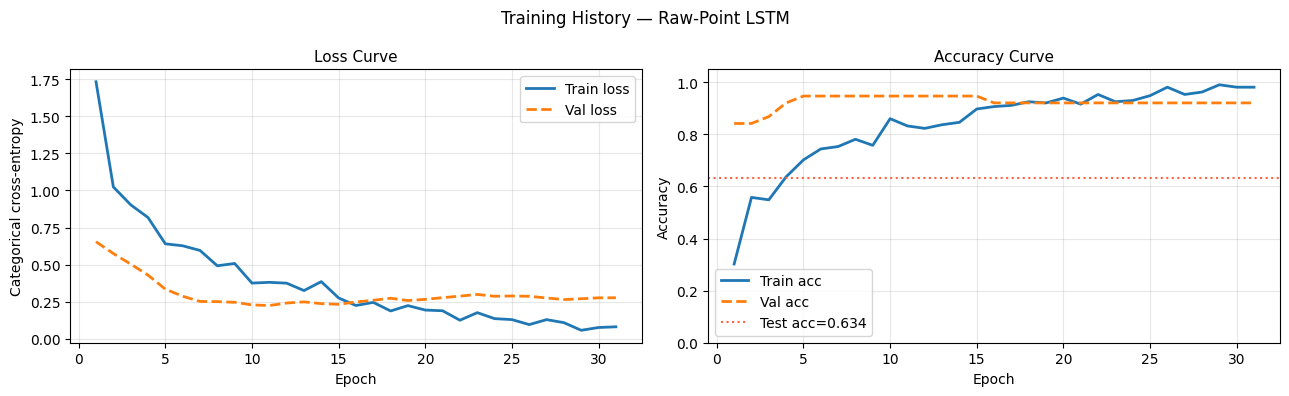

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_ran = range(1, len(history.history['loss']) + 1)

axes[0].plot(epochs_ran, history.history['loss'],     label='Train loss',  linewidth=2)
axes[0].plot(epochs_ran, history.history['val_loss'], label='Val loss',    linewidth=2, linestyle='--')
axes[0].set_title('Loss Curve', fontsize=11)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Categorical cross-entropy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history.history['accuracy'],     label='Train acc',  linewidth=2)
axes[1].plot(epochs_ran, history.history['val_accuracy'], label='Val acc',    linewidth=2, linestyle='--')
axes[1].axhline(test_acc, color='tomato', linewidth=1.5, linestyle=':',
                label=f'Test acc={test_acc:.3f}')
axes[1].set_title('Accuracy Curve', fontsize=11)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — Raw-Point LSTM', fontsize=12)
plt.tight_layout()
plt.savefig('raw_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Comparison — Raw-Point LSTM vs Feature-Engineered LSTM (Notebook 4)

Run Notebook 4 first and note its metrics, then fill the table below.

In [13]:
# ── Load Notebook 4 metrics from its saved model if available ──────────────────
nb4_results = {
    'Model':        'Feature-engineered (Nb4)',
    'Input dim':    '20 × 16',
    'Params':       '~22K',
    'Test Acc':     '(run Nb4 to fill)',
    'Macro F1':     '(run Nb4 to fill)',
    'Balanced Acc': '(run Nb4 to fill)',
}
nb5_results = {
    'Model':        'Raw-point (Nb5)',
    'Input dim':    f'20 × {FRAME_DIM}',
    'Params':       f'{model.count_params():,}',
    'Test Acc':     f'{test_acc:.4f}',
    'Macro F1':     f'{macro_f1:.4f}',
    'Balanced Acc': f'{bal_acc:.4f}',
}

cmp_df = pd.DataFrame([nb4_results, nb5_results])
print('\n=== Model Comparison ===')
print(cmp_df.to_string(index=False))

# ── Per-distance summary ───────────────────────────────────────────────────────
print('\nPer-distance accuracy (Raw-point LSTM):')
print(dist_df.to_string(index=False))


=== Model Comparison ===
                   Model Input dim Params          Test Acc          Macro F1      Balanced Acc
Feature-engineered (Nb4)   20 × 16   ~22K (run Nb4 to fill) (run Nb4 to fill) (run Nb4 to fill)
         Raw-point (Nb5)   20 × 80 39,460            0.6343            0.6493            0.6282

Per-distance accuracy (Raw-point LSTM):
Distance  Samples  Accuracy  Balanced Acc  Macro F1
     4 m       82    0.7683        0.7806    0.7719
     5 m       93    0.5161        0.4952    0.4677


## 11. Save Model & Scaler

In [14]:
import joblib

model.save('raw_points_lstm_classifier.keras')
print('Model saved → raw_points_lstm_classifier.keras')

joblib.dump(scaler, 'raw_points_feature_scaler.pkl')
print('Scaler saved → raw_points_feature_scaler.pkl')

joblib.dump(le, 'raw_points_label_encoder.pkl')
print('Label encoder saved → raw_points_label_encoder.pkl')

print('\n' + '=' * 60)
print('TRAINING SUMMARY — RAW-POINT LSTM')
print('=' * 60)
print(f'  Dataset        : Research Data-New / Single Activity')
print(f'  Representation : Raw points  (MAX_POINTS={MAX_POINTS}, {N_RAW} feats/pt)')
print(f'  Input shape    : ({WINDOW_SIZE}, {FRAME_DIM})')
print(f'  Model          : LSTM(64) + Dense(32)')
print(f'  Parameters     : {model.count_params():,}')
print(f'  Train windows  : {len(X_train)}')
print(f'  Test  windows  : {len(X_test)}')
print(f'  Test accuracy  : {test_acc:.4f}')
print(f'  Macro F1       : {macro_f1:.4f}')
print(f'  Balanced acc   : {bal_acc:.4f}')
print('=' * 60)

Model saved → raw_points_lstm_classifier.keras
Scaler saved → raw_points_feature_scaler.pkl
Label encoder saved → raw_points_label_encoder.pkl

TRAINING SUMMARY — RAW-POINT LSTM
  Dataset        : Research Data-New / Single Activity
  Representation : Raw points  (MAX_POINTS=10, 8 feats/pt)
  Input shape    : (20, 80)
  Model          : LSTM(64) + Dense(32)
  Parameters     : 39,460
  Train windows  : 253
  Test  windows  : 175
  Test accuracy  : 0.6343
  Macro F1       : 0.6493
  Balanced acc   : 0.6282


## Appendix — Quick Inference on a New Recording

In [15]:
def predict_activity(act, dist, model=model, scaler=scaler, le=le,
                     window_size=WINDOW_SIZE):
    frame_df = extract_raw_frames(act, dist)
    values   = frame_df[FLAT_COLS].values.astype(np.float32)

    seqs = []
    for start in range(0, len(values) - window_size + 1, STRIDE):
        seqs.append(values[start : start + window_size])

    if len(seqs) == 0:
        print(f'  Recording too short ({len(values)} frames < window {window_size})')
        return None, None

    X_new = np.array(seqs, dtype=np.float32)
    X_new = scaler.transform(X_new.reshape(-1, FRAME_DIM)).reshape(
        len(seqs), window_size, FRAME_DIM
    )

    probs = model.predict(X_new, verbose=0)
    votes = np.argmax(probs, axis=1)
    final = np.bincount(votes, minlength=NUM_CLASSES).argmax()

    return le.classes_[final], probs.max(axis=1).mean()


print('Inference demo (test distances):')
for act in ACTIVITIES:
    for dist in TEST_DISTS:
        pred, conf = predict_activity(act, dist)
        correct    = '✓' if pred == act else '✗'
        print(f'  {correct}  True={act:12}  Pred={str(pred):12}  Conf={conf:.3f}  Dist={dist}')

Inference demo (test distances):
  ✗  True=Sitting       Pred=Standing      Conf=0.555  Dist=4 m
  ✓  True=Sitting       Pred=Sitting       Conf=0.585  Dist=5 m
  ✓  True=Standing      Pred=Standing      Conf=0.640  Dist=4 m
  ✓  True=Standing      Pred=Standing      Conf=0.591  Dist=5 m
  ✓  True=Waiving       Pred=Waiving       Conf=0.862  Dist=4 m
  ✗  True=Waiving       Pred=Standing      Conf=0.715  Dist=5 m
  ✓  True=Walking       Pred=Walking       Conf=0.778  Dist=4 m
  ✓  True=Walking       Pred=Walking       Conf=0.787  Dist=5 m
